### Generate Surrogate Maps using BrainSMASH

This code will generate the surrogate maps (500) for a given seed. It will also plot the spatial autocorrelation of the empirical map vs the surrogate maps for validation.

**NOTE**: BrainSMASH was developed and tested using Python 3.7

**NOTE**: Using nibabel versions >2.1.0 will break the code. Therefore you need 

Therefore you need to use a different environment to run this step


**Make sure you check the file paths if running this script again! Things may have changed since you last ran it**

In [1]:
# Imports
import numpy as np
from brainsmash.mapgen.base import Base
from brainsmash.mapgen.eval import base_fit
import os

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Load all receptor map vectors
dopamine = np.load('/home/frank/HBNM/data/receptor_vectors/y_vector_dopamine.npy')
gaba = np.load('/home/frank/HBNM/data/receptor_vectors/y_vector_gaba.npy')
myelin = np.load('/home/frank/HBNM/data/receptor_vectors/y_vector_myelin.npy')
nmda = np.load('/home/frank/HBNM/data/receptor_vectors/y_vector_nmda.npy')
norepinephrine = np.load('/home/frank/HBNM/data/receptor_vectors/y_vector_norepinephrine.npy')
D = np.load("/home/frank/HBNM/experiments/spatial_lag_model/geodesic_distance_matrix.npy")

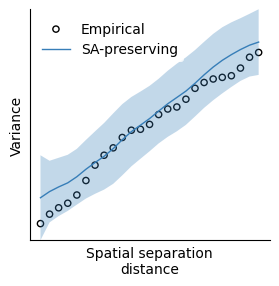

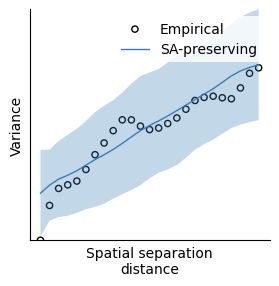

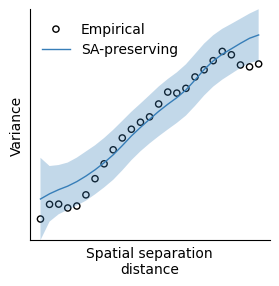

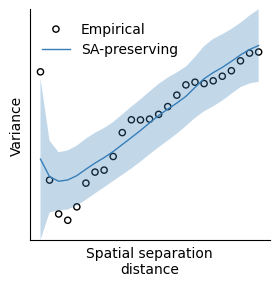

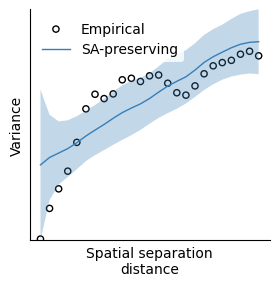

In [3]:
# Generate surrogates and fits for all brain maps
maps = {
    'dopamine': dopamine,
    'gaba': gaba,
    'myelin': myelin,
    'nmda': nmda,
    'norepinephrine': norepinephrine
}

surrogates_dict = {}
fits_dict = {}

for map_name, brain_map in maps.items():
    base = Base(x=brain_map, D=D, nh=40, resample=True)
    surrogates_dict[map_name] = base(n=100)
    fits_dict[map_name] = base_fit(brain_map, D, nsurr=100)

In [4]:
# Save the surrogate maps
import nibabel as nib

# Use an existing pscalar.nii file as template for saving individual surrogates
template_file = '/home/frank/HBNM/data/maps/dopamine_avg.pscalar.nii'
template_img = nib.load(template_file)

# Create main directory if it doesn't exist
os.makedirs('/home/frank/HBNM/data/surrogate_maps', exist_ok=True)

# Save each set of surrogate maps
for map_name, surrogates in surrogates_dict.items():
    # Create sub-folder for each receptor type
    receptor_dir = f'/home/frank/HBNM/data/surrogate_maps/{map_name}'
    os.makedirs(receptor_dir, exist_ok=True)
    
    # Save the full array as an npy file
    np.save(f'{receptor_dir}/{map_name}_surrogates.npy', surrogates)
    
    # Save each individual surrogate as a pscalar.nii file
    for i in range(surrogates.shape[0]):  # Loop through each surrogate (100 total)
        # Reshape surrogate data to match template shape (1, 180)
        surrogate_data = surrogates[i].reshape(1, -1)  # Shape: (1, n_vertices)
        
        # Create new CIFTI2 image using the template's header
        new_img = nib.Cifti2Image(surrogate_data, header=template_img.header)
        
        # Save as pscalar.nii file
        surrogate_filename = f'{receptor_dir}/{map_name}_surrogate_{i+1:03d}.pscalar.nii'
        nib.save(new_img, surrogate_filename)
    
    print(f"Saved {surrogates.shape[0]} surrogates for {map_name}")

print("All surrogate maps saved successfully!")

Saved 100 surrogates for dopamine
Saved 100 surrogates for gaba
Saved 100 surrogates for myelin
Saved 100 surrogates for nmda
Saved 100 surrogates for norepinephrine
All surrogate maps saved successfully!


Generating surrogate vs empirical comparison plots...

Plotting Dopamine surrogate vs empirical comparison...
Empirical correlation crosses zero at distance: 92.50


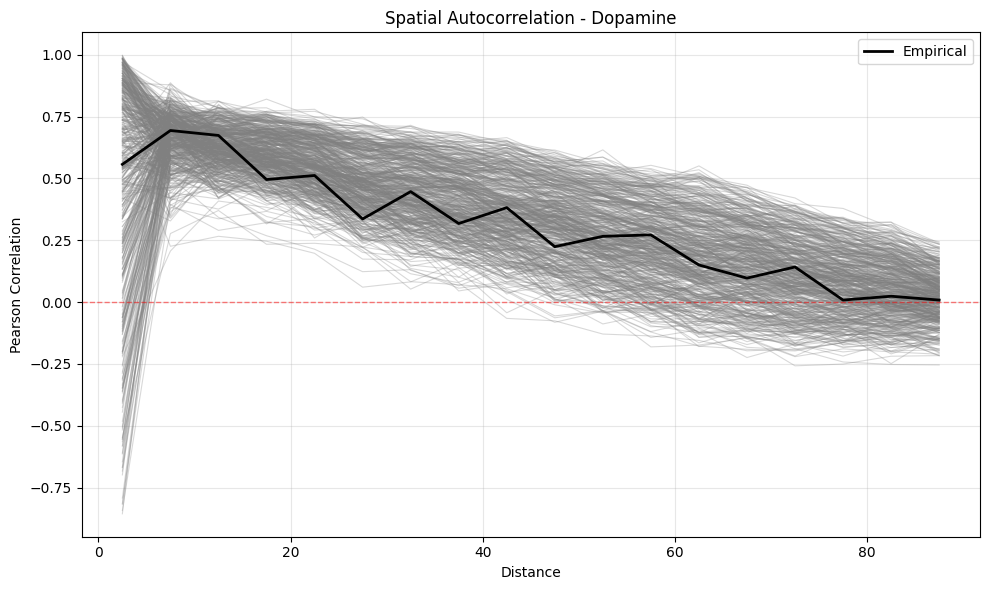


Plotting Gaba surrogate vs empirical comparison...
Empirical correlation crosses zero at distance: 102.50


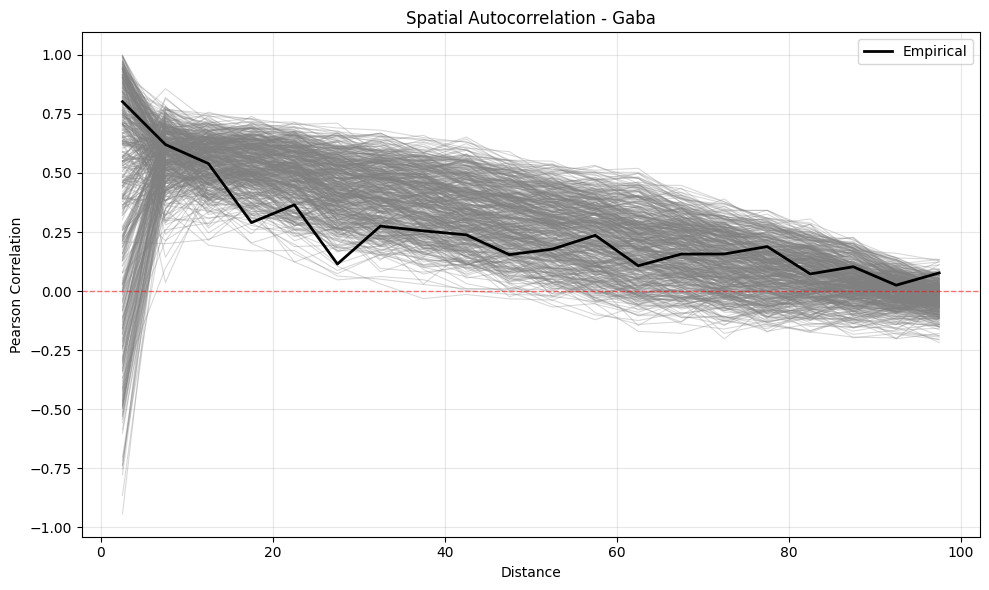


Plotting Myelin surrogate vs empirical comparison...
Empirical correlation crosses zero at distance: 107.50


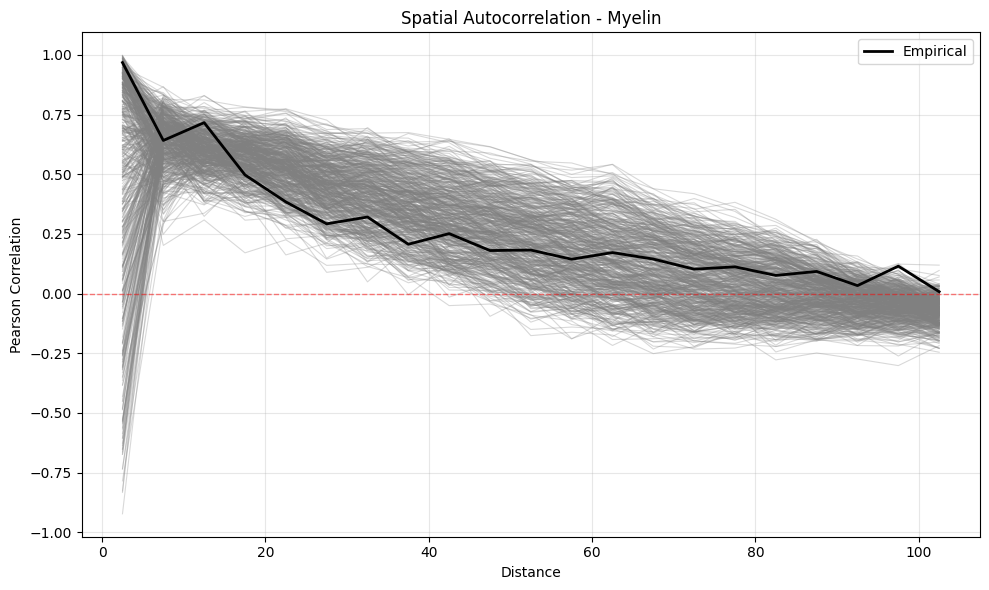


Plotting Nmda surrogate vs empirical comparison...
Empirical correlation crosses zero at distance: 62.50


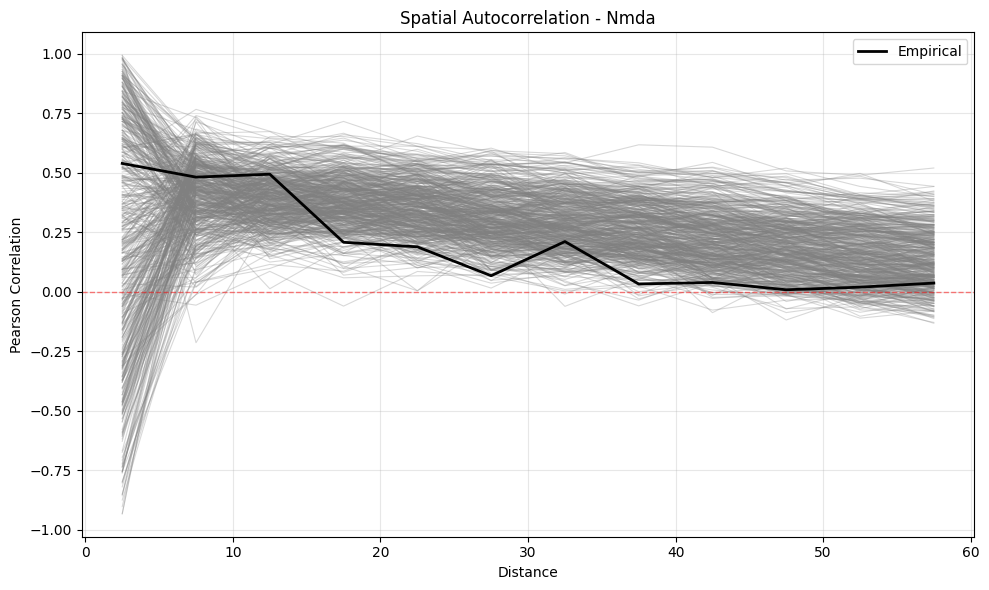


Plotting Norepinephrine surrogate vs empirical comparison...
Empirical correlation crosses zero at distance: 102.50


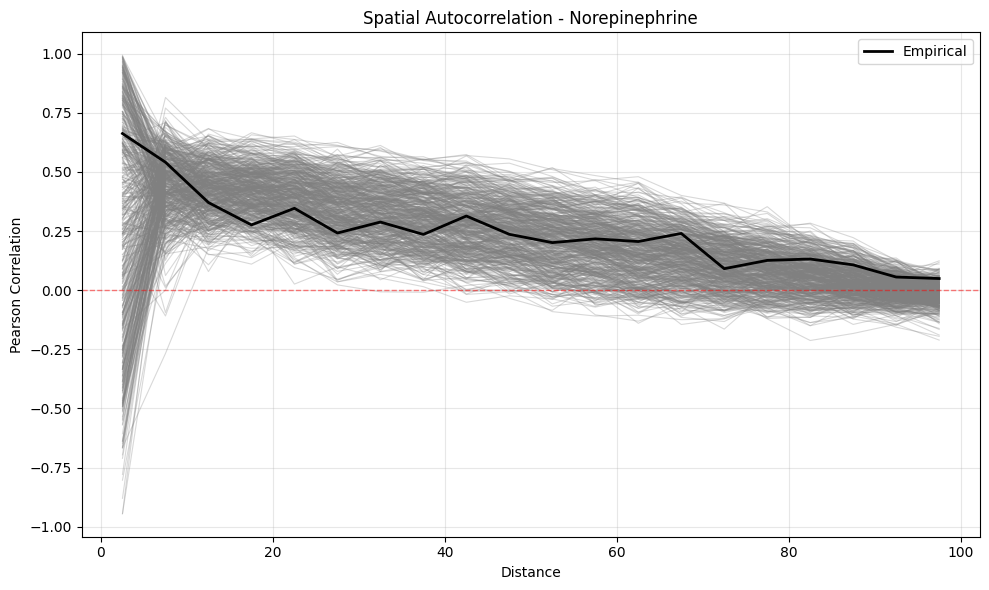

All surrogate vs empirical comparison plots generated!


In [5]:
# Validate Surrogate Maps

# Import required functions
import numpy as np
import matplotlib.pyplot as plt
from spatial_analysis_tools import compute_variogram

# Load distance matrix
D = np.load("/home/frank/HBNM/experiments/spatial_lag_model/geodesic_distance_matrix.npy")

# Load all receptor map vectors (empirical data)
receptor_maps = {
    'dopamine': np.load('/home/frank/HBNM/data/receptor_vectors/y_vector_dopamine.npy'),
    'gaba': np.load('/home/frank/HBNM/data/receptor_vectors/y_vector_gaba.npy'),
    'myelin': np.load('/home/frank/HBNM/data/receptor_vectors/y_vector_myelin.npy'),
    'nmda': np.load('/home/frank/HBNM/data/receptor_vectors/y_vector_nmda.npy'),
    'norepinephrine': np.load('/home/frank/HBNM/data/receptor_vectors/y_vector_norepinephrine.npy')
}

# Load all BrainSMASH surrogate maps
surrogate_maps = {
    'dopamine': np.load('/home/frank/HBNM/data/surrogate_maps/dopamine_surrogates.npy'),
    'gaba': np.load('/home/frank/HBNM/data/surrogate_maps/gaba_surrogates.npy'),
    'myelin': np.load('/home/frank/HBNM/data/surrogate_maps/myelin_surrogates.npy'),
    'nmda': np.load('/home/frank/HBNM/data/surrogate_maps/nmda_surrogates.npy'),
    'norepinephrine': np.load('/home/frank/HBNM/data/surrogate_maps/norepinephrine_surrogates.npy')
}


# Create plots for each receptor type
print("Generating surrogate vs empirical comparison plots...")

# 1. Standard BrainSMASH surrogate comparisons for all receptor types
for map_name in receptor_maps.keys():
    print(f"\nPlotting {map_name.capitalize()} surrogate vs empirical comparison...")
    fig = compute_variogram(
        D, 
        surrogate_maps[map_name], 
        receptor_maps[map_name], 
        map_name=f"{map_name.capitalize()}", 
        bin_width=5
    )
    plt.show()

print("All surrogate vs empirical comparison plots generated!")